# Hands On!

In [1]:
from tensorflow import keras 
from keras import layers 
from keras.models import Sequential
from keras.layers import Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt 

import sys
sys.path.append("../00-storage")
from dataset import load_hoda

In [2]:
load_hoda()

(array([[153, 229,   0, ...,   0,   0,   0],
        [  0,   0, 255, ..., 255, 153, 204],
        [255, 255, 255, ..., 255, 128,   0],
        ...,
        [  0,   0,   0, ..., 255,   0,   0],
        [  0, 194, 255, ...,   0,   0, 255],
        [255, 255,   0, ...,   0, 255, 204]], dtype=uint8),
 array([6, 5, 0, 2, 7, 0, 7, 5, 0, 7, 0, 6, 3, 6, 5, 5, 3, 3, 2, 9, 6, 3,
        4, 4, 0, 7, 2, 7, 8, 6, 0, 9, 8, 3, 2, 9, 4, 8, 8, 5, 4, 0, 3, 3,
        3, 2, 0, 8, 6, 0, 7, 5, 3, 5, 9, 2, 5, 3, 4, 9, 7, 9, 1, 9, 9, 7,
        1, 3, 4, 7, 8, 1, 4, 0, 4, 1, 1, 8, 1, 8, 2, 6, 2, 8, 0, 5, 9, 5,
        7, 6, 3, 4, 6, 5, 5, 9, 6, 2, 0, 9, 1, 2, 3, 2, 5, 8, 7, 4, 4, 8,
        7, 9, 9, 5, 7, 6, 9, 2, 9, 5, 7, 2, 5, 9, 5, 8, 4, 3, 2, 2, 2, 8,
        0, 3, 0, 6, 0, 9, 4, 0, 8, 6, 6, 7, 8, 1, 7, 8, 1, 0, 2, 8, 9, 9,
        4, 1, 6, 9, 0, 2, 6, 1, 9, 2, 0, 3, 0, 5, 3, 8, 9, 8, 5, 5, 6, 1,
        8, 6, 7, 3, 1, 6, 9, 4, 3, 5, 1, 0, 3, 6, 3, 0, 2, 7, 9, 3, 4, 0,
        5, 8, 1, 9, 4, 8, 9, 8, 0, 5

In [3]:
x_train, y_train, x_test, y_test = load_hoda(training_sample_size=3500, test_sample_size=400 , size=28)

# Preprocess input data 

### Normalize out data values to the range [0,1]

In [4]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")
x_train /= 255 
x_test /= 255 

### Reshape to original image shape (n * 784) => (n * 28 * 28 * 1)

In [5]:
x_train = x_train.reshape(-1 , 28 , 28 , 1)
x_test = x_test.reshape(-1 , 28 , 28 , 1)

### Preprocess class labels

In [6]:
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

### Define model architecture 

In [7]:
model = Sequential()

model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation="relu"))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation="relu"))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))
model.add(Dropout(0.5))
model.add(layers.Dense(10, activation="softmax"))

C:\Users\GIGA\anaconda3\envs\tf\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile model

In [8]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

### Fit model on training data

In [9]:
history = model.fit(x_train, y_train, epochs=200, batch_size=256, validation_split=0.2)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.2621 - loss: 2.1794 - val_accuracy: 0.5871 - val_loss: 1.8733
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5079 - loss: 1.5976 - val_accuracy: 0.7300 - val_loss: 0.9952
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6411 - loss: 1.0674 - val_accuracy: 0.8114 - val_loss: 0.6473
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7339 - loss: 0.8093 - val_accuracy: 0.8586 - val_loss: 0.4611
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7689 - loss: 0.6883 - val_accuracy: 0.8886 - val_loss: 0.3793
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8050 - loss: 0.5845 - val_accuracy: 0.8886 - val_loss: 0.3435
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8293 - loss: 0.5025 - val_accuracy: 0.8986 - val_loss: 0.2741
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8643 - loss: 0.4144 - val_accuracy: 0.

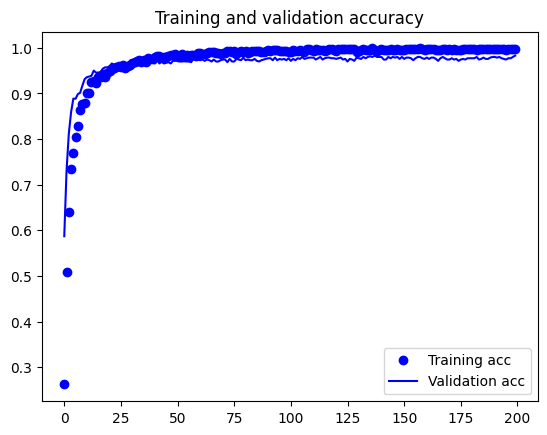

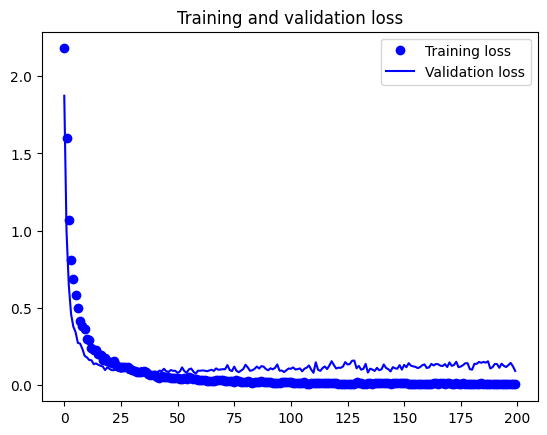

In [10]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(acc))

plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.legend()

plt.figure()

plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()